# Preparação dos dados — Dormidas turísticas por NUTS II (Turismo de Portugal)

**Projeto:** O Preço da Guerra 
**Autor:** Luis Miguel Pereira Silva · PG60390 
**Universidade:** Universidade do Minho — Mestrado em IA 
**Disciplina:** SVDC 

---

## Fonte

[Turismo de Portugal — TravelBI](https://travelbi.turismodeportugal.pt/) 
*Permanência de Hóspedes / Dormidas por NUTS II e tipologia*. Frequência mensal.

Ficheiro original: `data/serie_dormidas_NUTS2024.zip` 
Sub-ficheiro usado: `serie_dormidas_NUTS2024/dormidas_tipologia.xlsx` 
Ficheiro produzido: `data/dormidas_regiao.csv`

## Estrutura do xlsx

Uma sheet por ano (2023, 2024, 2025, 2026). Em cada sheet:
- Linha 0: título da tabela
- Linhas 2–3: ano + meses como cabeçalho
- Linha 4: **total da região** (`Norte`, `Centro`, ...)
- Linhas 5+: tipologia dentro da região (`Hotéis`, `5*`, etc.) — não nos interessam

Estratégia: para cada região, ler apenas a **primeira linha** (total) e descartar as restantes até à próxima região.


In [1]:
import pandas as pd
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
ZIP  = RAW / 'serie_dormidas_NUTS2024.zip'


## 1. Extrair o xlsx


In [2]:
import io, tempfile
with zipfile.ZipFile(ZIP) as z:
    print('Conteúdo:', z.namelist())
    with z.open('serie_dormidas_NUTS2024/dormidas_tipologia.xlsx') as f:
        xlsx_bytes = io.BytesIO(f.read())

xl = pd.ExcelFile(xlsx_bytes)
print('Sheets:', xl.sheet_names)


Conteúdo: ['serie_dormidas_NUTS2024/', 'serie_dormidas_NUTS2024/dormidas_mercado.xlsx', 'serie_dormidas_NUTS2024/dormidas_tipologia.xlsx']
Sheets: ['2023', '2024', '2025', '2026']


## 2. Função para extrair os totais regionais de uma sheet


In [3]:
# NUTS 2024 — sub-regiões oficiais de Portugal Continental + RA
# (a partir de 2024 a NUTS partiu a antiga AML em três e renomeou as RA)
REGIOES = {
    'Norte', 'Centro', 'Oeste e Vale do Tejo',
    'Grande Lisboa', 'Península de Setúbal',
    'Alentejo', 'Algarve',
    'Açores', 'Madeira'
}

MESES = {'janeiro':1,'fevereiro':2,'março':3,'abril':4,'maio':5,'junho':6,
         'julho':7,'agosto':8,'setembro':9,'outubro':10,'novembro':11,'dezembro':12}

def extract_year(xlsx_bytes, sheet_name):
    """Devolve DataFrame long-format (date, region, dormidas) para uma sheet."""
    raw = pd.read_excel(xlsx_bytes, sheet_name=sheet_name, header=None)
    year = int(sheet_name)
    rows = []
    for i, val in raw.iloc[:, 0].items():
        if val in REGIOES:
            # Linha da região = linha de totais (12 meses em cols 1-12)
            line = raw.iloc[i, 1:13].tolist()
            for mes_idx, dorm in enumerate(line, start=1):
                # Ignorar NaN e valores confidenciais ('…' ou strings)
                if pd.isna(dorm) or isinstance(dorm, str):
                    continue
                try:
                    rows.append({
                        'date'    : pd.Timestamp(year=year, month=mes_idx, day=1),
                        'region'  : val,
                        'dormidas': int(dorm)
                    })
                except (ValueError, TypeError):
                    pass
    return pd.DataFrame(rows)

frames = [extract_year(xlsx_bytes, s) for s in xl.sheet_names]
df = pd.concat(frames, ignore_index=True).sort_values(['date','region']).reset_index(drop=True)
print(f'Total: {len(df)} linhas, {df.date.min().date()} → {df.date.max().date()}')
print(f'Regiões: {sorted(df.region.unique())}')
df.head(10)


Total: 342 linhas, 2023-01-01 → 2026-02-01
Regiões: ['Alentejo', 'Algarve', 'Açores', 'Centro', 'Grande Lisboa', 'Madeira', 'Norte', 'Oeste e Vale do Tejo', 'Península de Setúbal']


,date,region,dormidas
0,2023-01-01,Alentejo,113861
1,2023-01-01,Algarve,546804
2,2023-01-01,Açores,93145
3,2023-01-01,Centro,255478
4,2023-01-01,Grande Lisboa,1055139
5,2023-01-01,Madeira,591405
6,2023-01-01,Norte,600832
7,2023-01-01,Oeste e Vale do Tejo,109160
8,2023-01-01,Península de Setúbal,68509
9,2023-02-01,Alentejo,155131


## 3. Sanity check — totais por região (acumulado 2024)


In [4]:
totais_2024 = df[df.date.dt.year == 2024].groupby('region').dormidas.sum().sort_values(ascending=False)
print(totais_2024.to_string())


region
Algarve                 20738937
Grande Lisboa           19460452
Norte                   14104757
Madeira                  9552517
Centro                   5167312
Oeste e Vale do Tejo     3482178
Alentejo                 3257042
Açores                   3027576
Península de Setúbal     1564062


## 4. Visualização


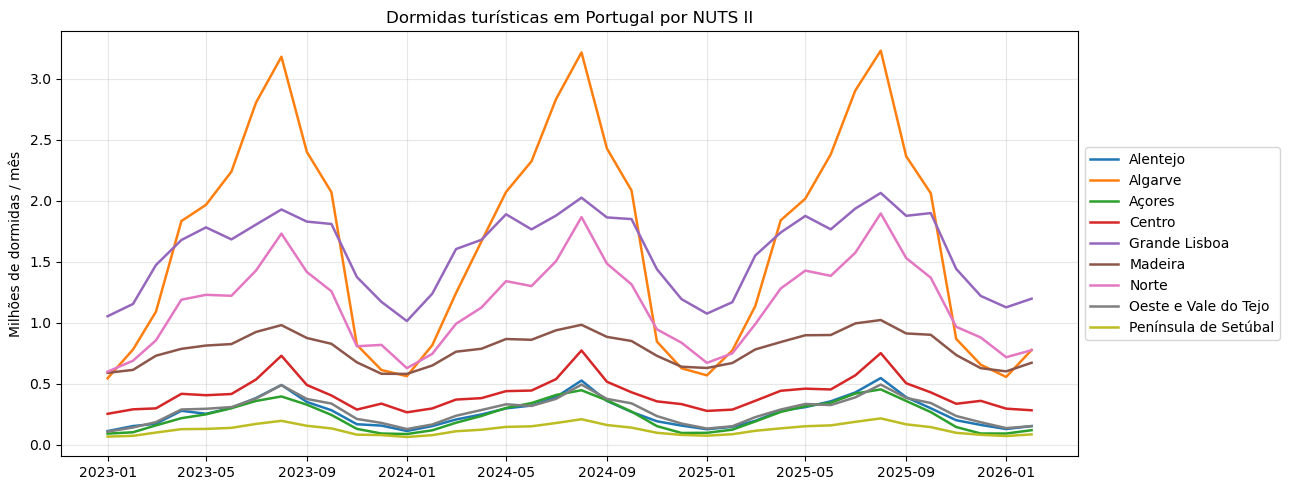

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for reg, g in df.groupby('region'):
    ax.plot(g.date, g.dormidas / 1e6, label=reg, linewidth=1.8)
ax.set_ylabel('Milhões de dormidas / mês')
ax.set_title('Dormidas turísticas em Portugal por NUTS II')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Exportar


In [6]:
out = PROCESSED / 'dormidas_regiao.csv'
df.to_csv(out, index=False)
print('✓ Gravado em', out)


✓ Gravado em ..\data\dormidas_regiao.csv


---

## ✓ Resultado

`data/dormidas_regiao.csv` em formato long (`date, region, dormidas`).

**Nota narrativa:** este dataset não está usado no D3 atualmente, mas serve como *backup* 
se quisermos correlacionar a guerra (e o aumento dos combustíveis) com uma quebra do turismo 
interno (carro próprio) numa eventual extensão do projeto.
